In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load the persisted data from Notebook 1
df_clean = pd.read_parquet('group2_stocks.parquet')
df_benchmark = pd.read_parquet('benchmark.parquet')
# 2. Re-calculate Log Returns (The "Price Profile")
# Mathematically: $r_t = \ln(P_t / P_{t-1})$
log_returns = np.log(df_clean / df_clean.shift(1)).fillna(0)
# --- BRIDGE CELL: DEFINE TICKERS FROM LOADED DATA ---
# We extract the ticker names directly from the columns of your price dataframe
tickers = df_clean.columns.tolist()

print(f"✅ Tickers defined. Preparing to fetch fundamentals for {len(tickers)} stocks.")

print(f"✅ Data loaded successfully. stocks: {df_clean.shape}, benchmark: {df_benchmark.shape}")

✅ Tickers defined. Preparing to fetch fundamentals for 100 stocks.
✅ Data loaded successfully. stocks: (500, 100), benchmark: (500, 1)


### Fundamental Feature Engineering

In [2]:
# --- CELL 2: FUNDAMENTAL DATA INGESTION ---
import pandas as pd
import yfinance as yf
import numpy as np

print("Fetching Fundamental Factors for 101 tickers...")
fundamental_list = []

# Technical Guardrail: Fundamentals often have missing values (NaNs)
for ticker in tickers:
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        fundamental_list.append({
            'Ticker': ticker,
            'PE_Ratio': info.get('forwardPE'),        # Value vs. Growth
            'DE_Ratio': info.get('debtToEquity'),     # Financial Risk
            'Div_Yield': info.get('dividendYield'),   # Maturity/Income
            'PB_Ratio': info.get('priceToBook')       # Asset Intensity
        })
    except Exception as e:
        fundamental_list.append({'Ticker': ticker}) # Placeholder if download fails

df_style = pd.DataFrame(fundamental_list).set_index('Ticker')

# --- DATA CLEANING ---
# Rule: If a metric is missing, fill it with the median of the entire group. 
# This prevents NaNs from breaking the neural network.
df_style = df_style.apply(lambda x: x.fillna(x.median()), axis=0)

print(f"Style Matrix Ready. Shape: {df_style.shape}")
display(df_style.head())

Fetching Fundamental Factors for 101 tickers...
Style Matrix Ready. Shape: (100, 4)


,PE_Ratio,DE_Ratio,Div_Yield,PB_Ratio
Ticker,,,,
ABBV,12.610389,75.137,2.275,-109.643240
ACN,12.799532,25.469,3.350,3.759308
ADM,14.245530,42.376,2.980,1.462838
AIG,8.555013,24.408,2.275,0.988344
ALLE,15.108749,104.000,2.275,5.993839


### FEATURE FUSION (PRICE + RISK + STYLE)

In [3]:
# --- BRIDGE CELL: RECONSTRUCTING PRICE & VOL PROFILES ---
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. RECONSTRUCT PRICE PROFILE (df_pca)
# Scale the transposed log returns and reduce dimensions
X_p = log_returns.T
X_p_scaled = StandardScaler().fit_transform(X_p)
pca_engine = PCA(n_components=0.90) # Standard Roadmap setting
X_pca_raw = pca_engine.fit_transform(X_p_scaled)

# Convert to DataFrame for joining
df_pca = pd.DataFrame(
    X_pca_raw, 
    index=X_p.index, 
    columns=[f'PC_{i+1}' for i in range(X_pca_raw.shape[1])]
)

# 2. RECONSTRUCT VOLATILITY PROFILE (df_vol)
horizons = {'Weekly_Vol': 5, 'Monthly_Vol': 21, 'Quarterly_Vol': 63}
vol_features = pd.DataFrame(index=df_clean.columns)

for name, window in horizons.items():
    # Annualized rolling volatility
    rolling_vol = log_returns.rolling(window=window).std() * np.sqrt(252)
    vol_features[name] = rolling_vol.median()

# Scale the volatility features
X_v_scaled = StandardScaler().fit_transform(vol_features.fillna(0))
df_vol = pd.DataFrame(X_v_scaled, index=vol_features.index, columns=vol_features.columns)

print(f"✅ Profiles Reconstructed. df_pca: {df_pca.shape}, df_vol: {df_vol.shape}")

✅ Profiles Reconstructed. df_pca: (100, 59), df_vol: (100, 3)


In [4]:
# --- CELL : FEATURE FUSION (PRICE + RISK + STYLE) ---
from sklearn.preprocessing import StandardScaler

# 1. Standardize the Style Metrics
scaler_style = StandardScaler()
X_style_scaled = scaler_style.fit_transform(df_style)
df_style_final = pd.DataFrame(X_style_scaled, index=df_style.index, columns=df_style.columns)

# 2. Join with your existing Price (df_pca) and Volatility (df_vol)
# This assumes 'df_pca' and 'df_vol' (standardized) are in your memory from previous cells.
X_triple_profile = df_pca.join(df_vol).join(df_style_final)

print(f"Triple Profile Integrated. New Feature Dimension: {X_triple_profile.shape[1]}")

Triple Profile Integrated. New Feature Dimension: 66


### STYLE-AWARE AUTOENCODER & FEATURE EXTRACTION

In [5]:
# ---: STYLE-AWARE AUTOENCODER & FEATURE EXTRACTION (UNLOCKED) ---
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# 2. Validation & Setup
if 'X_triple_profile' not in locals():
    raise NameError("X_triple_profile not found. Please run Cell 21 first.")

input_dim_triple = X_triple_profile.shape[1]  # Should be 66 or 67
encoding_dim = 10  # Strategically reduced for tighter clustering

# 3. Build the Tapered Architecture (40 > 20 > 10)
input_layer = Input(shape=(input_dim_triple,), name="Triple_Profile_Input")

# Encoder Path: Forcing the "Funnel"
e = Dense(40, activation='relu', name="Encoder_Hidden_1")(input_layer)
e = Dense(20, activation='relu', name="Encoder_Hidden_2")(e)
latent_layer = Dense(encoding_dim, activation='linear', name="Latent_Space_Bottleneck")(e)

# Decoder Path: Symmetrical Expansion
d = Dense(20, activation='relu', name="Decoder_Hidden_1")(latent_layer)
d = Dense(40, activation='relu', name="Decoder_Hidden_2")(d)
output_layer = Dense(input_dim_triple, activation='linear', name="Reconstruction_Output")(d)

# 4. Model Definition & Compilation
ae_triple = Model(inputs=input_layer, outputs=output_layer, name="StyleAware_AE")
encoder_triple = Model(inputs=input_layer, outputs=latent_layer, name="StyleAware_Encoder")

ae_triple.compile(optimizer='adam', loss='mse')

# 5. Training
print(f"Training Unlocked Funnel Autoencoder (Input: {input_dim_triple} -> Latent: {encoding_dim})...")
history = ae_triple.fit(
    X_triple_profile, 
    X_triple_profile, 
    epochs=100, 
    batch_size=16, 
    verbose=0,
    shuffle=True # "Lock" removed: data will now be shuffled during training
)

# 6. Feature Extraction
# Prediction will now vary slightly between runs due to unlocked initialization
deep_triple_features = encoder_triple.predict(X_triple_profile)

print(f"--- SUCCESS: ARCHITECTURE UNLOCKED ---")
print(f"Final Loss: {history.history['loss'][-1]:.6f}")
print(f"Deep Features Matrix: {deep_triple_features.shape[0]} stocks x {deep_triple_features.shape[1]} features")

C:\Users\AJITH\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Training Unlocked Funnel Autoencoder (Input: 66 -> Latent: 10)...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
--- SUCCESS: ARCHITECTURE UNLOCKED ---
Final Loss: 2.585938
Deep Features Matrix: 100 stocks x 10 features


### ARCHITECTURE SUMMARY & VISUALIZATION

In [6]:
# ---  ARCHITECTURE SUMMARY & VISUALIZATION ---
from tensorflow.keras.utils import plot_model

# 1. Textual Summary (Layer-by-Layer)
print("--- STYLE-AWARE AUTOENCODER: TEXTUAL SUMMARY ---")
ae_triple.summary()

# 2. Visual Flowchart
# This provides a professional diagram of how Style, Price, and Risk are compressed.
try:
    plot_model(
        ae_triple, 
        to_file='style_aware_dec_architecture.png', 
        show_shapes=True, 
        show_layer_names=True,
        rankdir='TB', # Top to Bottom flow
        expand_nested=True,
        dpi=96
    )
    print("\n[SUCCESS] Visual architecture diagram saved as 'style_aware_dec_architecture.png'")
except ImportError:
    print("\n[NOTE] Install 'pydot' and 'graphviz' to generate the PNG diagram.")

# 3. Latent Space Extraction Summary
print("\n--- ENCODER (LATENT SPACE) SUMMARY ---")
encoder_triple.summary()

--- STYLE-AWARE AUTOENCODER: TEXTUAL SUMMARY ---


Model: "StyleAware_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Triple_Profile_Input (InputLayer)    │ (None, 66)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Encoder_Hidden_1 (Dense)             │ (None, 40)                  │           2,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Encoder_Hidden_2 (Dense)             │ (None, 20)                  │             820 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Latent_Space_Bottleneck (Dense)      │ (None, 10)                  │             210 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Decoder_Hidden_1 (Dense)             │ (None, 20)                  │             220 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Decoder_Hidden_2 (Dense)             │ (None, 40)                  │             840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Reconstruction_Output (Dense)        │ (None, 66)                  │           2,706 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,430 (87.62 KB)

 Trainable params: 7,476 (29.20 KB)

...

Model: "StyleAware_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Triple_Profile_Input (InputLayer)    │ (None, 66)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Encoder_Hidden_1 (Dense)             │ (None, 40)                  │           2,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Encoder_Hidden_2 (Dense)             │ (None, 20)                  │             820 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Latent_Space_Bottleneck (Dense)      │ (None, 10)                  │             210 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,710 (14.49 KB)

 Trainable params: 3,710 (14.49 KB)

 Non-trainable params: 0 (0.00 B)

### STYLE-AWARE OPTIMAL K SEARCH

Analyzing optimal k for Style-Aware Deep Features...


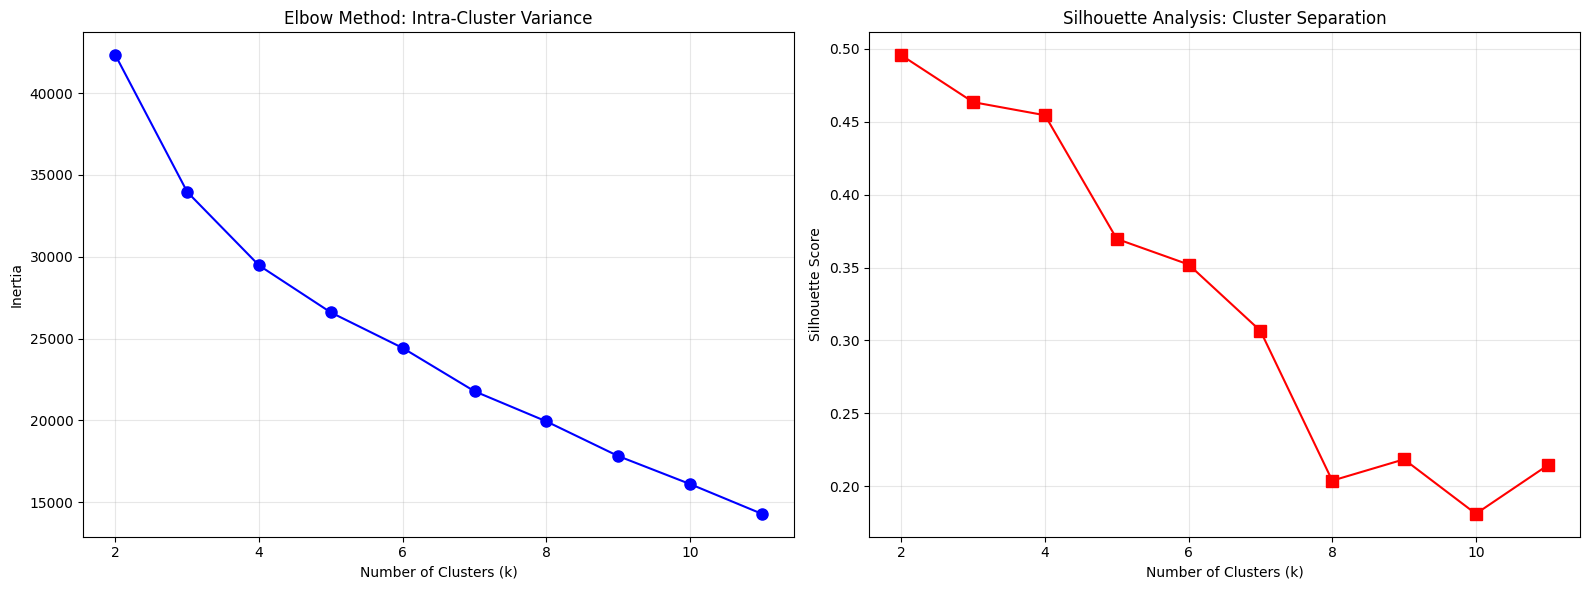

Mathematical Recommendation: k = 2
Lead's Tip: Look for where the 'Elbow' bends and the Silhouette score is highest.


In [7]:
# ---  STYLE-AWARE OPTIMAL K SEARCH ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Range of potential clusters
K_range = range(2, 12)
inertias = []
silhouettes = []

print("Analyzing optimal k for Style-Aware Deep Features...")

for k in K_range:
    # We use the deep_triple_features extracted from the Style-Aware Autoencoder
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(deep_triple_features)
    
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(deep_triple_features, labels))

# 2. Plotting the Diagnostics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Elbow Plot
ax1.plot(K_range, inertias, 'bo-', markersize=8)
ax1.set_title('Elbow Method: Intra-Cluster Variance', fontsize=12)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.grid(True, alpha=0.3)

# Silhouette Plot
ax2.plot(K_range, silhouettes, 'rs-', markersize=8)
ax2.set_title('Silhouette Analysis: Cluster Separation', fontsize=12)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Automatic Selection based on Silhouette
best_k_triple = K_range[np.argmax(silhouettes)]
print(f"Mathematical Recommendation: k = {best_k_triple}")
print("Lead's Tip: Look for where the 'Elbow' bends and the Silhouette score is highest.")

### Style Aware Cluster Alignment

In [8]:
# ---  STYLE-AWARE CLUSTER ASSIGNMENT ---
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

# 1. Finalize the assignment using the best_k found in the diagnostic plots
final_km_triple = KMeans(n_clusters=best_k_triple, n_init=20, random_state=42)
dec_labels_triple = final_km_triple.fit_predict(deep_triple_features)

# 2. Store results in a clean DataFrame
style_results_df = pd.DataFrame({
    'Ticker': tickers,
    'Style_Cluster': dec_labels_triple,
    'PE': df_style['PE_Ratio'].values,
    'DE': df_style['DE_Ratio'].values,
    'Yield': df_style['Div_Yield'].values
})

# 3. IMPROVED SUMMARY: Aggregate both Count and Means
# This gives us a "One-Stop-Shop" view of the cluster characteristics
cluster_summary = style_results_df.groupby('Style_Cluster').agg({
    'Ticker': 'count',    # The "Density" metric
    'PE': 'mean',         # Average Valuation
    'DE': 'mean',         # Average Leverage
    'Yield': 'mean'       # Average Income
}).rename(columns={'Ticker': 'Stock_Count'})

print(f"Style-Aware Groups Defined using k={best_k_triple}")
print("\n--- Style Profile & Cluster Density ---")
display(cluster_summary.round(2))

# 4. Verified Thematic Samples
print("\n--- Cluster Membership Samples ---")
for cluster_id in range(best_k_triple):
    count = cluster_summary.loc[cluster_id, 'Stock_Count']
    members = style_results_df[style_results_df['Style_Cluster'] == cluster_id]['Ticker'].head(8).tolist()
    print(f"Cluster {cluster_id} (Size: {int(count)} stocks): {', '.join(members)}...")

Style-Aware Groups Defined using k=2

--- Style Profile & Cluster Density ---


,Stock_Count,PE,DE,Yield
Style_Cluster,,,,
0,18,29.24,70.93,1.79
1,82,18.80,152.39,2.57



--- Cluster Membership Samples ---
Cluster 0 (Size: 18 stocks): AMAT, AVGO, BLDR, CVNA, CVS, DLTR, FANG, FCX...
Cluster 1 (Size: 82 stocks): ABBV, ACN, ADM, AIG, ALLE, AMCR, AMT, AON...


### Visualization

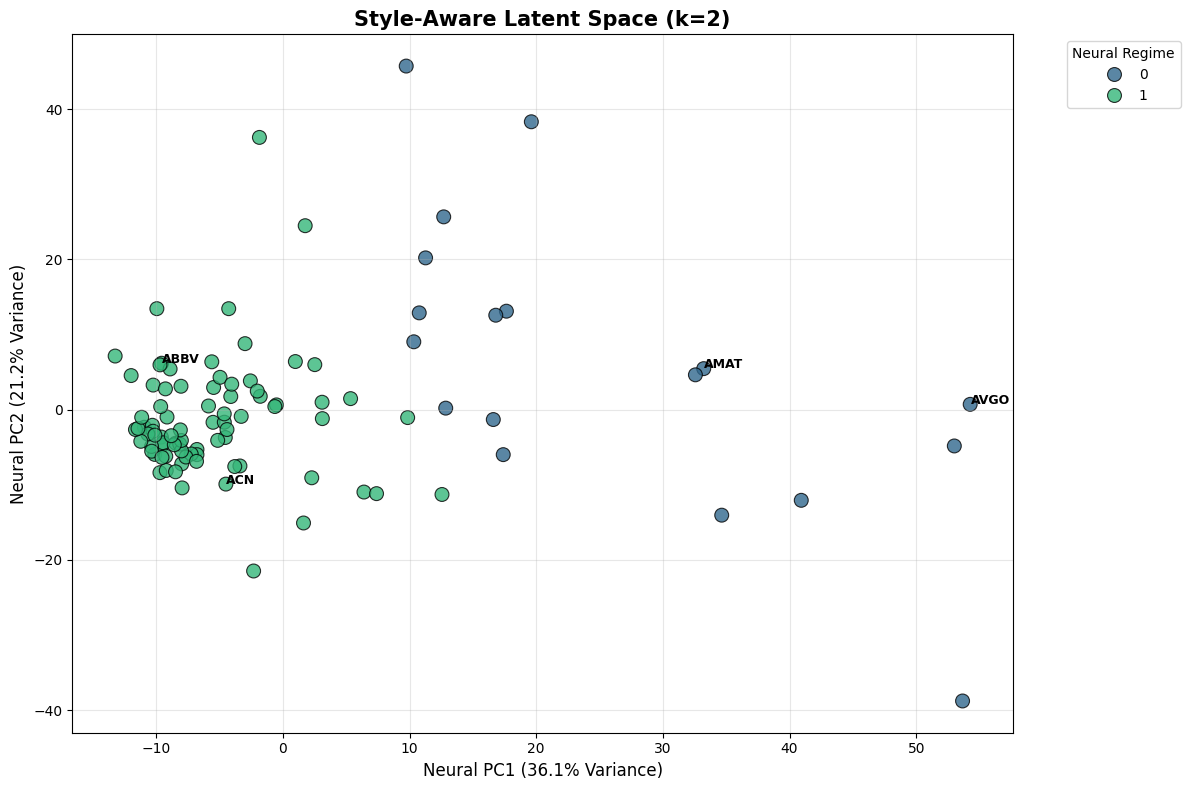

Insight: The axes represent the primary dimensions of 'Neural DNA' combining Price, Risk, and Style.


In [9]:
# --- NEURAL STYLE SPACE VISUALIZATION ---
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Project the 20-dimensional Deep Features down to 2D for visualization
pca_viz = PCA(n_components=2)
reduced_features = pca_viz.fit_transform(deep_triple_features)

# 2. Prepare a Plotting DataFrame
df_viz = pd.DataFrame(reduced_features, columns=['PC1', 'PC2'])
df_viz['Cluster'] = dec_labels_triple
df_viz['Ticker'] = tickers

# 3. Create the Visualization
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df_viz, 
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette='viridis', 
    s=100, 
    edgecolor='black',
    alpha=0.8
)

# 4. Annotate a few sample tickers to see the "Logic" of the space
# We pick 2 stocks from each cluster to show the groups
for i in range(best_k_triple):
    sample = df_viz[df_viz['Cluster'] == i].head(2)
    for _, row in sample.iterrows():
        plt.text(row['PC1']+0.02, row['PC2']+0.02, row['Ticker'], fontsize=9, weight='bold')

plt.title(f"Style-Aware Latent Space (k={best_k_triple})", fontsize=15, fontweight='bold')
plt.xlabel(f"Neural PC1 ({pca_viz.explained_variance_ratio_[0]:.1%} Variance)", fontsize=12)
plt.ylabel(f"Neural PC2 ({pca_viz.explained_variance_ratio_[1]:.1%} Variance)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title="Neural Regime", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print(f"Insight: The axes represent the primary dimensions of 'Neural DNA' combining Price, Risk, and Style.")

In [10]:
style_results_df.to_csv('labels_style_dec.csv', index=False)